In [1]:
from glob import glob
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO



In [2]:
# check all folders whose names ends with _fasta_files
fasta_files = glob("**/*_fasta_files", recursive=True)

# split the name of the folder using "_" as a separator and get the first part
fasta_files = [Path(f).parts[0] for f in fasta_files]

# print the names 
print(fasta_files)


['PP2C77_fasta_files', 'CLPD1_fasta_files', 'AGO18_fasta_files', 'CBL8_fasta_files', 'JAMYB_fasta_files', 'NAC77_fasta_files', 'OAT_fasta_files', 'CIPK17_fasta_files', 'brca1_fasta_files']


In [3]:
# from each folder get the evo2_delta_score_1b.csv file
my_evo2_delta_score_1b = []
for folder in fasta_files:
    # get the path of the file
    file = os.path.join(folder, "evo2_delta_score_1b.csv")
    
    # check if the file exists and add the path to the list
    if os.path.exists(file):
        print(f"File {file} exists")
        my_evo2_delta_score_1b.append(file)

    else:
        print(f"File {file} does not exist")
        pass

# check if the file is a csv file

File PP2C77_fasta_files/evo2_delta_score_1b.csv exists
File CLPD1_fasta_files/evo2_delta_score_1b.csv exists
File AGO18_fasta_files/evo2_delta_score_1b.csv exists
File CBL8_fasta_files/evo2_delta_score_1b.csv exists
File JAMYB_fasta_files/evo2_delta_score_1b.csv exists
File NAC77_fasta_files/evo2_delta_score_1b.csv exists
File OAT_fasta_files/evo2_delta_score_1b.csv exists
File CIPK17_fasta_files/evo2_delta_score_1b.csv exists
File brca1_fasta_files/evo2_delta_score_1b.csv does not exist


In [4]:

# create a dictionary from the table
dictionary_of_correct_reference_names = {
    "CBL8": "HAP7_Freq.15315",
    "CIPK17": "HAP56_Freq.6124",
    "NAC77": "HAP21_Freq.13677",
    "CLPD1": "HAP26_Freq.1370",
    "OAT": "HAP12_Freq.13256",
    "PP2C77": "HAP20_Freq.8975",
    "JAMYB": "HAP58_Freq.4474",
    "AGO18": "HAP72_Freq.7084",
}

In [5]:
dictionary_of_correct_reference_names["OAT"]

'HAP12_Freq.13256'

In [6]:
# declare an empty list to store the dataframes
my_dfs = []
for file in my_evo2_delta_score_1b:
    # read the file with pandas
    my_csv = pd.read_csv(file)
    # add a column with the name of the folder
    my_csv["Gene"] = file.split("_")[0] 
    # replace the names of the column ref_fasta_name with the correct names
    my_csv.drop(columns=["ref_fasta_name"], inplace=True)
    my_csv["ref_fasta_name"] = dictionary_of_correct_reference_names[file.split("_")[0]]
    #keep the order ref_fasta_name,var_fasta_name,ref_log_probs,var_log_probs,evo2_delta_score
    my_csv = my_csv[["ref_fasta_name", "var_fasta_name", "ref_log_probs", "var_log_probs", "evo2_delta_score", "Gene"]]
    # add the dataframe to the list
    my_dfs.append(my_csv)
# concatenate the dataframes
my_df = pd.concat(my_dfs, ignore_index=True)
    

In [7]:
my_df.head()

,ref_fasta_name,var_fasta_name,ref_log_probs,var_log_probs,evo2_delta_score,Gene
0,HAP20_Freq.8975,HAP10_Freq.6,-5.726811,-5.738573,-0.011762,PP2C77
1,HAP20_Freq.8975,HAP11_Freq.7,-5.726811,-5.907400,-0.180588,PP2C77
2,HAP20_Freq.8975,HAP12_Freq.8,-5.726811,-5.868585,-0.141774,PP2C77
3,HAP20_Freq.8975,HAP13_Freq.8,-5.726811,-5.672090,0.054722,PP2C77
4,HAP20_Freq.8975,HAP14_Freq.8,-5.726811,-5.710376,0.016436,PP2C77


In [8]:
def plot_strip_with_means(df, x_col="evo2_delta_score", class_col="Gene"):
    """Creates a strip plot with jittered points and median indicators for each class using Seaborn.

    Parameters:
    - df (pd.DataFrame): The input DataFrame containing data.
    - x_col (str): The column name representing the x-axis values (e.g., evo2_delta_score).
    - class_col (str): The column name representing the class labels.

    Returns:
    - matplotlib Figure: Strip plot with median indicators.
    """
    # NVIDIA theme colors
    NVIDIA_GREEN = "#76B900"
    BACKGROUND_COLOR = "#F8F8F8"
    GRID_COLOR = "#DDDDDD"
    FONT_COLOR = "#333333"

    # Determine order of classes (if not already specified)
    unique_classes = sorted(df[class_col].unique())

    # Set up the plot with NVIDIA theme
    plt.figure(figsize=(9, 5), facecolor=BACKGROUND_COLOR)
    plt.style.use("default")  # Reset to default to avoid any pre-existing style

    # Create strip plot
    p = sns.stripplot(
        data=df,
        x=x_col,
        y=class_col,
        hue=class_col,
        order=unique_classes,
        # palette=[NVIDIA_GREEN, "red"],
        palette="colorblind",
        size=6,
        jitter=0.3,
        alpha=0.6,
    )

    # Add median indicators using boxplot
    sns.boxplot(
        showmeans=True,
        meanline=True,
        meanprops={"visible": False},
        medianprops={"color": "black", "ls": "-", "lw": 2},
        whiskerprops={"visible": False},
        zorder=10,
        x=x_col,
        y=class_col,
        data=df,
        order=unique_classes,
        showfliers=False,
        showbox=False,
        showcaps=False,
        ax=p,
    )

    # Customize plot appearance
    plt.title(
        "Distribution of Delta Likelihoods Scores",
        color=FONT_COLOR,
        fontsize=12,
        loc="left",
    )
    plt.xlabel("Delta Likelihood Score, Evo 2", color=FONT_COLOR)
    plt.ylabel("GENE NAMES", color=FONT_COLOR)

    # Customize grid and tick colors
    plt.grid(color=GRID_COLOR, axis="x", linestyle="--", linewidth=0.5)
    plt.tick_params(colors=FONT_COLOR)

    # Set background color
    plt.gca().set_facecolor(BACKGROUND_COLOR)
    plt.gcf().set_facecolor(BACKGROUND_COLOR)

    # Desapear legend
    plt.legend().set_visible(False)

    plt.tight_layout()


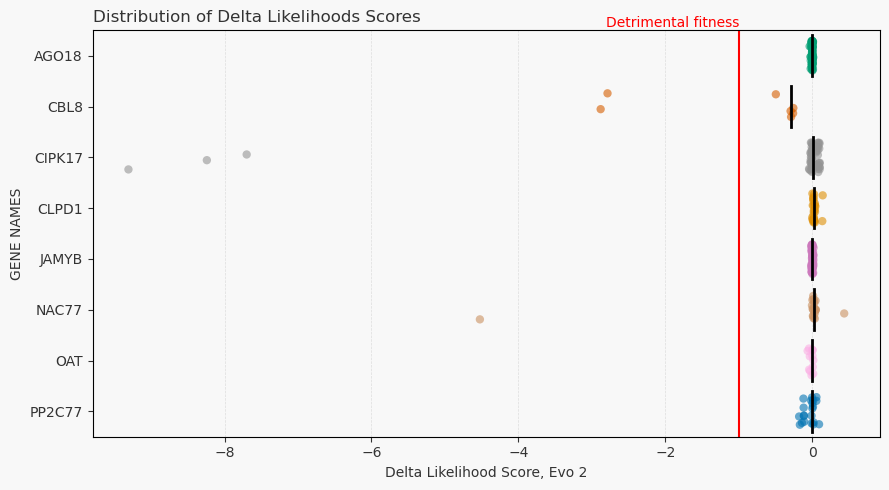

In [9]:
plot_strip_with_means(my_df, x_col="evo2_delta_score", class_col="Gene")
## add a red line at x=-1
plt.axvline(x=-1, color='red')
# add a text label "Detrimental fitness" at the top of the line
plt.text(-1, plt.ylim()[1], "Detrimental fitness", color='red', ha='right', va='bottom')
# Save the plot in high resolution and the images folder
plt.savefig("../images/evo2_delta_score_strip_plot.svg", dpi=300)

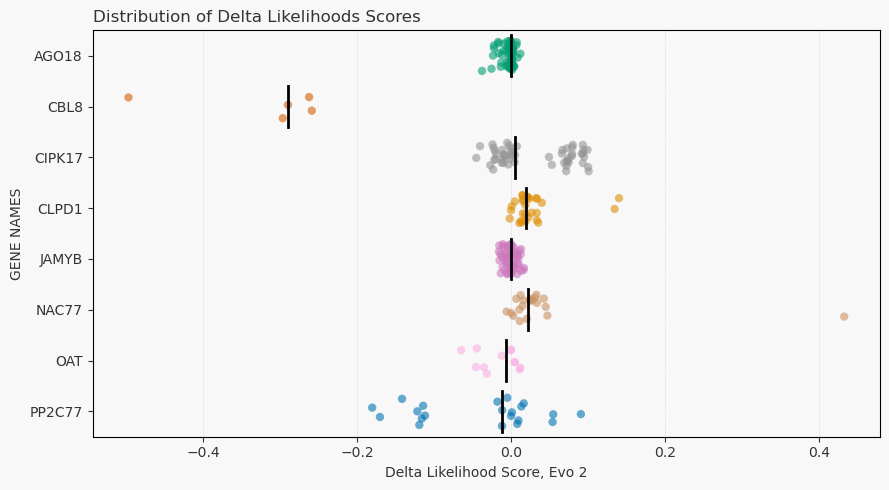

In [10]:
# select the rows where evo2_delta_score is greater than -1
# my_df = my_df[my_df["evo2_delta_score"] > -1]
plot_strip_with_means(my_df[my_df["evo2_delta_score"] > -1], x_col="evo2_delta_score", class_col="Gene")

In [16]:
def plot_strip_with_density(df, x_col="evo2_delta_score", class_col="Gene"):
    """Strip plot with KDE contours to highlight clusters."""
    NVIDIA_GREEN = "#76B900"
    BACKGROUND_COLOR = "#F8F8F8"
    GRID_COLOR = "#DDDDDD"
    FONT_COLOR = "#333333"
    
    unique_classes = sorted(df[class_col].unique())
    
    fig, ax = plt.subplots(figsize=(9, 5), facecolor=BACKGROUND_COLOR)
    
    # Strip plot
    sns.stripplot(
        data=df, x=x_col, y=class_col, hue=class_col,
        order=unique_classes, palette="colorblind",
        size=6, jitter=0.3, alpha=0.2, ax=ax
    )
    
    # Add KDE violin overlay (semi-transparent)
    sns.violinplot(
        data=df, x=x_col, y=class_col, order=unique_classes,
        inner=None, density_norm="count", alpha=0.1,
        palette="colorblind", ax=ax
    )
    
    # Median lines
    sns.boxplot(
        showmeans=False, medianprops={"color": "black", "ls": "-", "lw": 2},
        whiskerprops={"visible": False}, zorder=10,
        x=x_col, y=class_col, data=df, order=unique_classes,
        showfliers=False, showbox=False, showcaps=False, ax=ax
    )
    
    ax.set_title("Distribution with Density Overlay", color=FONT_COLOR, fontsize=12, loc="left")
    ax.set_xlabel("Delta Likelihood Score, Evo 2", color=FONT_COLOR)
    ax.set_ylabel("GENE NAMES", color=FONT_COLOR)
    ax.grid(color=GRID_COLOR, axis="x", linestyle="--", linewidth=0.5)
    ax.legend().set_visible(False)
    plt.tight_layout()

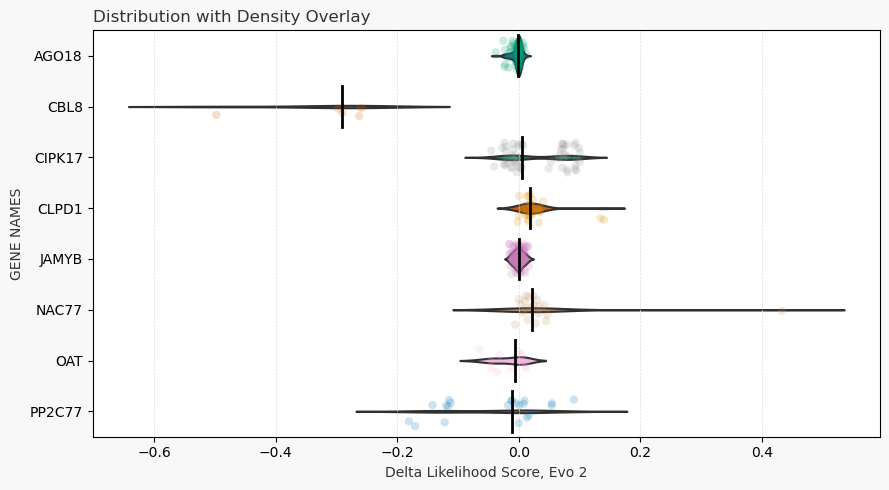

In [17]:
plot_strip_with_density(my_df[my_df["evo2_delta_score"] > -1], x_col="evo2_delta_score", class_col="Gene")

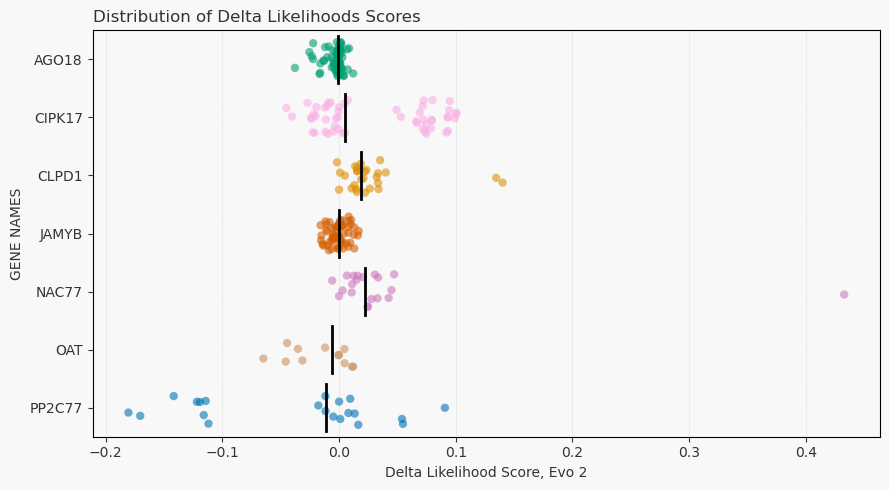

In [11]:
plot_strip_with_means(my_df[my_df["evo2_delta_score"] > -0.2], x_col="evo2_delta_score", class_col="Gene")

In [12]:
# These variants are sequences too short to produce any viable protein
my_df[my_df["evo2_delta_score"] < -1]

,ref_fasta_name,var_fasta_name,ref_log_probs,var_log_probs,evo2_delta_score,Gene
121,HAP7_Freq.15315,HAP1_Freq.5,-7.832271,-10.620499,-2.788228,CBL8
125,HAP7_Freq.15315,HAP5_Freq.363,-7.832271,-10.713840,-2.881570,CBL8
189,HAP21_Freq.13677,HAP12_Freq.33,-5.866140,-10.391085,-4.524945,NAC77
226,HAP56_Freq.6124,HAP16_Freq.6,-5.834435,-13.533226,-7.698791,CIPK17
230,HAP56_Freq.6124,HAP1_Freq.4,-5.834435,-14.074990,-8.240555,CIPK17
262,HAP56_Freq.6124,HAP49_Freq.344,-5.834435,-15.142140,-9.307705,CIPK17


In [13]:
my_df[my_df["evo2_delta_score"] > 0.2]

,ref_fasta_name,var_fasta_name,ref_log_probs,var_log_probs,evo2_delta_score,Gene
205,HAP21_Freq.13677,HAP7_Freq.9,-5.86614,-5.433164,0.432976,NAC77


In [14]:
# explore the df with the designated evo2_delta_score
my_df[(my_df["evo2_delta_score"] < 0.01) & (my_df["Gene"]=="NAC77")].sort_values(by="evo2_delta_score", ascending=False)

,ref_fasta_name,var_fasta_name,ref_log_probs,var_log_probs,evo2_delta_score,Gene
197,HAP21_Freq.13677,HAP1_Freq.4,-5.86614,-5.859448,0.006692,NAC77
204,HAP21_Freq.13677,HAP6_Freq.7,-5.86614,-5.863173,0.002966,NAC77
199,HAP21_Freq.13677,HAP21_Freq.13677,-5.86614,-5.866140,0.000000,NAC77
201,HAP21_Freq.13677,HAP3_Freq.5,-5.86614,-5.872056,-0.005916,NAC77
189,HAP21_Freq.13677,HAP12_Freq.33,-5.86614,-10.391085,-4.524945,NAC77


In [15]:
# lets write a funtion that adds the length of the sequence to the dataframe
def add_length_of_sequence(df,gene_name ,col_name="var_fasta_name"):
    """Adds the length of the sequence to the dataframe.

    Parameters:
    - df (pd.DataFrame): The input DataFrame containing data.
    - col_name (str): The column name representing the sequence names.

    Returns:
    - pd.DataFrame: DataFrame with an additional column for sequence lengths.
    """
    # establish the realtoive path 
    path_to_seq_file = f"{gene_name}_fasta_files/{gene_name}_variants.fasta"
    # read the fasta file
    for record in SeqIO.parse(path_to_seq_file, "fasta"):
        # get the sequence name
        seq_name = record.id
        # get the sequence
        seq = str(record.seq)
        # get the length of the sequence
        seq_length = len(seq)
        # refine the seletion on the dataframe to only mathc the col name and the gene name
        df = df.loc[df["Gene"] == gene_name]
        # add the length of the sequence to the dataframe
        df.loc[df[col_name] == seq_name, "length"] = seq_length
        # add the sequence to the dataframe
        # df.loc[df[col_name] == seq_name, "length"] = seq_length
        # df["length"] = df.loc[df[col_name] == seq_name] = seq
    # Get the length of the sequence
    
    return df
# add the length of the sequence to the dataframe

In [16]:
test = add_length_of_sequence(df=my_df, gene_name="NAC77", col_name="var_fasta_name")

/var/folders/r4/f19fk2nx1p9cf_8x9720lc_w14v44f/T/ipykernel_24748/3109832073.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df[col_name] == seq_name, "length"] = seq_length


In [17]:
test[test["Gene"]=="NAC77"].sort_values(by="evo2_delta_score", ascending=False)

,ref_fasta_name,var_fasta_name,ref_log_probs,var_log_probs,evo2_delta_score,Gene,length
205,HAP21_Freq.13677,HAP7_Freq.9,-5.86614,-5.433164,0.432976,NAC77,396.0
198,HAP21_Freq.13677,HAP20_Freq.2538,-5.86614,-5.819002,0.047138,NAC77,396.0
193,HAP21_Freq.13677,HAP16_Freq.55,-5.86614,-5.821215,0.044925,NAC77,396.0
206,HAP21_Freq.13677,HAP8_Freq.9,-5.86614,-5.823654,0.042486,NAC77,396.0
187,HAP21_Freq.13677,HAP10_Freq.11,-5.86614,-5.832668,0.033472,NAC77,396.0
188,HAP21_Freq.13677,HAP11_Freq.16,-5.86614,-5.833188,0.032952,NAC77,396.0
202,HAP21_Freq.13677,HAP4_Freq.5,-5.86614,-5.835503,0.030637,NAC77,396.0
200,HAP21_Freq.13677,HAP2_Freq.5,-5.86614,-5.838475,0.027665,NAC77,396.0
195,HAP21_Freq.13677,HAP18_Freq.72,-5.86614,-5.841528,0.024611,NAC77,396.0
196,HAP21_Freq.13677,HAP19_Freq.2368,-5.86614,-5.841761,0.024379,NAC77,396.0


In [18]:
another_list_of_dfs = []
# iterate over the dictionary of correct reference names
for gene in dictionary_of_correct_reference_names.keys():
    # get the name of the gene
    gene_name = gene
    # add the length of the sequence to the dataframe
    temp_df = add_length_of_sequence(my_df, gene_name, col_name="var_fasta_name")
    # add the dataframe to the list
    another_list_of_dfs.append(temp_df)
# concatenate the dataframes
my_df = pd.concat(another_list_of_dfs, ignore_index=True)



/var/folders/r4/f19fk2nx1p9cf_8x9720lc_w14v44f/T/ipykernel_24748/3109832073.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df[col_name] == seq_name, "length"] = seq_length
/var/folders/r4/f19fk2nx1p9cf_8x9720lc_w14v44f/T/ipykernel_24748/3109832073.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df[col_name] == seq_name, "length"] = seq_length
/var/folders/r4/f19fk2nx1p9cf_8x9720lc_w14v44f/T/ipykernel_24748/3109832073.py:25: SettingWithCopyWarning: 
A value is trying to be set on a c

In [19]:
my_df[my_df["Gene"]=="NAC77"].sort_values(by="evo2_delta_score", ascending=False)

,ref_fasta_name,var_fasta_name,ref_log_probs,var_log_probs,evo2_delta_score,Gene,length
81,HAP21_Freq.13677,HAP7_Freq.9,-5.86614,-5.433164,0.432976,NAC77,396.0
74,HAP21_Freq.13677,HAP20_Freq.2538,-5.86614,-5.819002,0.047138,NAC77,396.0
69,HAP21_Freq.13677,HAP16_Freq.55,-5.86614,-5.821215,0.044925,NAC77,396.0
82,HAP21_Freq.13677,HAP8_Freq.9,-5.86614,-5.823654,0.042486,NAC77,396.0
63,HAP21_Freq.13677,HAP10_Freq.11,-5.86614,-5.832668,0.033472,NAC77,396.0
64,HAP21_Freq.13677,HAP11_Freq.16,-5.86614,-5.833188,0.032952,NAC77,396.0
78,HAP21_Freq.13677,HAP4_Freq.5,-5.86614,-5.835503,0.030637,NAC77,396.0
76,HAP21_Freq.13677,HAP2_Freq.5,-5.86614,-5.838475,0.027665,NAC77,396.0
71,HAP21_Freq.13677,HAP18_Freq.72,-5.86614,-5.841528,0.024611,NAC77,396.0
72,HAP21_Freq.13677,HAP19_Freq.2368,-5.86614,-5.841761,0.024379,NAC77,396.0


In [20]:
my_df[(my_df["evo2_delta_score"] > 0.02) & (my_df["Gene"]=="NAC77")].sort_values(by="evo2_delta_score", ascending=False)

,ref_fasta_name,var_fasta_name,ref_log_probs,var_log_probs,evo2_delta_score,Gene,length
81,HAP21_Freq.13677,HAP7_Freq.9,-5.86614,-5.433164,0.432976,NAC77,396.0
74,HAP21_Freq.13677,HAP20_Freq.2538,-5.86614,-5.819002,0.047138,NAC77,396.0
69,HAP21_Freq.13677,HAP16_Freq.55,-5.86614,-5.821215,0.044925,NAC77,396.0
82,HAP21_Freq.13677,HAP8_Freq.9,-5.86614,-5.823654,0.042486,NAC77,396.0
63,HAP21_Freq.13677,HAP10_Freq.11,-5.86614,-5.832668,0.033472,NAC77,396.0
64,HAP21_Freq.13677,HAP11_Freq.16,-5.86614,-5.833188,0.032952,NAC77,396.0
78,HAP21_Freq.13677,HAP4_Freq.5,-5.86614,-5.835503,0.030637,NAC77,396.0
76,HAP21_Freq.13677,HAP2_Freq.5,-5.86614,-5.838475,0.027665,NAC77,396.0
71,HAP21_Freq.13677,HAP18_Freq.72,-5.86614,-5.841528,0.024611,NAC77,396.0
72,HAP21_Freq.13677,HAP19_Freq.2368,-5.86614,-5.841761,0.024379,NAC77,396.0


In [21]:
my_df[my_df["Gene"]=="CIPK17"].sort_values(by="evo2_delta_score", ascending=False)

,ref_fasta_name,var_fasta_name,ref_log_probs,var_log_probs,evo2_delta_score,Gene,length
43,HAP56_Freq.6124,HAP43_Freq.68,-5.834435,-5.733672,0.100763,CIPK17,454.0
37,HAP56_Freq.6124,HAP38_Freq.32,-5.834435,-5.734354,0.100081,CIPK17,454.0
38,HAP56_Freq.6124,HAP39_Freq.32,-5.834435,-5.735127,0.099308,CIPK17,454.0
47,HAP56_Freq.6124,HAP47_Freq.204,-5.834435,-5.739540,0.094895,CIPK17,454.0
41,HAP56_Freq.6124,HAP41_Freq.59,-5.834435,-5.740117,0.094318,CIPK17,454.0
44,HAP56_Freq.6124,HAP44_Freq.90,-5.834435,-5.741129,0.093306,CIPK17,454.0
39,HAP56_Freq.6124,HAP3_Freq.4,-5.834435,-5.741269,0.093166,CIPK17,454.0
42,HAP56_Freq.6124,HAP42_Freq.60,-5.834435,-5.741363,0.093072,CIPK17,454.0
56,HAP56_Freq.6124,HAP55_Freq.4952,-5.834435,-5.742554,0.091881,CIPK17,454.0
53,HAP56_Freq.6124,HAP52_Freq.947,-5.834435,-5.754347,0.080088,CIPK17,454.0


In [22]:
my_df[my_df["Gene"]=="CBL8"].sort_values(by="evo2_delta_score", ascending=False)

,ref_fasta_name,var_fasta_name,ref_log_probs,var_log_probs,evo2_delta_score,Gene,length
5,HAP7_Freq.15315,HAP6_Freq.3062,-7.832271,-8.091366,-0.259095,CBL8,213.0
3,HAP7_Freq.15315,HAP4_Freq.135,-7.832271,-8.094887,-0.262616,CBL8,213.0
2,HAP7_Freq.15315,HAP3_Freq.130,-7.832271,-8.122319,-0.290049,CBL8,213.0
6,HAP7_Freq.15315,HAP7_Freq.15315,-7.832271,-8.129118,-0.296847,CBL8,213.0
1,HAP7_Freq.15315,HAP2_Freq.12,-7.832271,-8.329682,-0.497412,CBL8,213.0
0,HAP7_Freq.15315,HAP1_Freq.5,-7.832271,-10.620499,-2.788228,CBL8,91.0
4,HAP7_Freq.15315,HAP5_Freq.363,-7.832271,-10.713840,-2.881570,CBL8,91.0


In [23]:
my_df[my_df["evo2_delta_score"] < -1]

,ref_fasta_name,var_fasta_name,ref_log_probs,var_log_probs,evo2_delta_score,Gene,length
0,HAP7_Freq.15315,HAP1_Freq.5,-7.832271,-10.620499,-2.788228,CBL8,91.0
4,HAP7_Freq.15315,HAP5_Freq.363,-7.832271,-10.713840,-2.881570,CBL8,91.0
13,HAP56_Freq.6124,HAP16_Freq.6,-5.834435,-13.533226,-7.698791,CIPK17,13.0
17,HAP56_Freq.6124,HAP1_Freq.4,-5.834435,-14.074990,-8.240555,CIPK17,13.0
49,HAP56_Freq.6124,HAP49_Freq.344,-5.834435,-15.142140,-9.307705,CIPK17,13.0
65,HAP21_Freq.13677,HAP12_Freq.33,-5.866140,-10.391085,-4.524945,NAC77,74.0


In [24]:
def get_fasta_based_on_delta(df, delta_value=0.01, gene_name="NAC77", delta_positive=True):
    """Creates a fasta file with the sequences that have a delta value greater than the specified value.

    Parameters:
    - df (pd.DataFrame): The input DataFrame containing data.
    - delta_value (float): The threshold for delta values to filter sequences.

    Returns:
    - None
    """

    # establish the path to the fasta file
    fasta_file = f"{gene_name}_fasta_files/{gene_name}_variants.fasta"
    # get the name of the variants with positive delta values
    if delta_positive:
        df_pos_delta = df[(df["evo2_delta_score"] >= delta_value) & (df["Gene"]==f"{gene_name}")].sort_values(by="evo2_delta_score", ascending=False)
        length_mode =  df_pos_delta["length"].mode().values[0]
        output_file = f"{gene_name}_fasta_files/{gene_name}_variants_pos_delta.fasta"
    # get the name of the variants with negative delta values
    else:
        df_pos_delta = df[(df["evo2_delta_score"] < delta_value) & (df["Gene"]==f"{gene_name}")].sort_values(by="evo2_delta_score", ascending=True)
        length_mode =  df_pos_delta["length"].mode().values[0]
        output_file = f"{gene_name}_fasta_files/{gene_name}_variants_neg_delta.fasta"


    # select by comlumn length , is the lenght is less thena the mode do not include it
    df_pos_delta = df_pos_delta[df_pos_delta["length"] >= length_mode ] 
    list_to_seq = df_pos_delta.var_fasta_name.to_list()
    list_to_seq.append(df_pos_delta.ref_fasta_name.to_list()[0])
    # add to the list the name of the reference sequence
    # nac77_pos_delta = nac77_pos_delta.append({"ref_fasta_name": nac77_pos_delta.ref_fasta_name.to_list()[0]}, ignore_index=True)
    # get the sequences from the fasta file

    # create a list to store the sequences
    my_sequences = []
    # read the fasta file
    for record in SeqIO.parse(fasta_file, "fasta"):
        # get the name of the sequence
        name = record.id
        # check if the name is in the list of names
        if name in list_to_seq:
            # add the sequence to the list
            my_sequences.append(record)
    # create a new fasta file with the sequences
    SeqIO.write(my_sequences, output_file, "fasta")


In [25]:
# lets do it for all the genes
for gene in dictionary_of_correct_reference_names.keys():
    # get the name of the gene
    gene_name = gene
    # calculate the median value of the delta score
    median_value = my_df[(my_df["Gene"]==gene_name)]["evo2_delta_score"].median()
    # get the fasta file with the positive delta values
    get_fasta_based_on_delta(my_df, delta_value=median_value, gene_name=gene_name)
    # get the fasta file with the negative delta values
    get_fasta_based_on_delta(my_df, delta_value=median_value, gene_name=gene_name, delta_positive=False)

In [26]:

get_fasta_based_on_delta(my_df, delta_value=0.02, gene_name="NAC77")

get_fasta_based_on_delta(my_df, delta_value=0.049, gene_name="CIPK17")

get_fasta_based_on_delta(my_df, delta_value=0.02, gene_name="NAC77",delta_positive=False) # this is the median value
get_fasta_based_on_delta(my_df, delta_value=0.049, gene_name="CIPK17",delta_positive=False) # this is the median value
get_fasta_based_on_delta(my_df, delta_value=-0.2, gene_name="CBL8",delta_positive=False) # this is the median value

CBL8 HAP2_Freq.12 vs WT is clear 
We need to complete the clustal aligments for the other genes 
